#  Is the Golden Leaf Still Profitable?
Seasonal Trend Analysis and Profitability in the face of climate and economic pressure (2015-2025)

**This project follows  through the sales analysis of tobacco in zimbabwe as compared against factors like climate and inflation rates
 
Key objectives:
- Analyze historical tobacco prices and sales volumes (local vs. export).
- Identify and interpret seasonal and annual trends.
- Quantify the impact of weather (rainfall, droughts) and inflation on sales and profits.
- Forecast future prices and profitability using time-series and regression models.
- Provide actionable recommendations for farmers and industry stakeholders.
- Build a clear, interactive dashboard for communicating insights.

Loading Raw Data

In [2]:
import pandas as pd
df = pd.read_csv('C:/Users/user/Desktop/tobacco sales analysis datasets/tobacco_sales.csv',delimiter=';')
df.head()

,Date,Year,Day_Number,Auction_Weight_Kg,Auction_Price_USD,Contract_Weight_Kg,Contract_Price_USD,Combined_Weight_Kg,Combined_Price_USD,Prev_Year_Weight,Prev_Year_Price,Rejection_Rate_Auction,Rejection_Rate_Contract
0,22-07-2025,2025,96,19507119,3.57,328566854.0,3.31,348073973.0,3.33,228632202.0,3.43,NaN,NaN
1,21-07-2025,2025,95,19467767,3.57,328263865.0,3.31,347731632.0,3.33,228452621.0,3.43,NaN,NaN
2,18-07-2025,2025,94,19427361,3.57,327847311.0,3.32,347274672.0,3.33,228184172.0,3.43,NaN,NaN
3,17-07-2025,2025,93,19397720,3.58,326699086.0,3.32,346096806.0,3.33,227798720.0,3.43,NaN,NaN
4,16-07-2025,2025,92,19328162,3.58,325608711.0,3.32,344936873.0,3.33,227026939.0,3.43,NaN,NaN


Standardizing columns, this is because:
1. data in normally inconsistent
2. allow for machine readability
3. comparability
4. easy analysis further down the line

In [3]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
print(df.columns.tolist())


['date', 'year', 'day_number', 'auction_weight_kg', 'auction_price_usd', 'contract_weight_kg', 'contract_price_usd', 'combined_weight_kg', 'combined_price_usd', 'prev_year_weight', 'prev_year_price', 'rejection_rate_auction', 'rejection_rate_contract']


In [4]:
df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y', errors='coerce')

In [5]:
invalid_dates = df[df['date'].isna()]
print(invalid_dates['date'])  # Should show empty (NaT) but inspect source column


Series([], Name: date, dtype: datetime64[ns])


Handling missing or inconsistent values

In [6]:
# Show number of missing values per column 
missing_counts = df.isnull().sum()
print("Missing values per column:\n", missing_counts)

Missing values per column:
 date                         0
year                         0
day_number                   0
auction_weight_kg            0
auction_price_usd           25
contract_weight_kg           2
contract_price_usd          16
combined_weight_kg         143
combined_price_usd         143
prev_year_weight           221
prev_year_price            221
rejection_rate_auction     215
rejection_rate_contract    280
dtype: int64


1. how can i use day number for analysis?
2. auction price to use mean price as a replacement but lets use mean according to year so yearly mean per missing value
3. contract weight use yearly mean as well
4. contract price we do the same as well
5. combined weight we add auction and contract weights and fill in the missing values butwe need to first confirm and check if thee are values in which the addition is not adding up and then we correct those
6. we do step 5 again on combined price
7. previous year weight and price we can drop the columns 
8. rejection rates for all we can use the online available data and use the yearly averages and fill it according to year


In [7]:
#ensuring data types are correct 
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   date                     375 non-null    datetime64[ns]
 1   year                     375 non-null    int64         
 2   day_number               375 non-null    int64         
 3   auction_weight_kg        375 non-null    int64         
 4   auction_price_usd        350 non-null    float64       
 5   contract_weight_kg       373 non-null    float64       
 6   contract_price_usd       359 non-null    float64       
 7   combined_weight_kg       232 non-null    float64       
 8   combined_price_usd       232 non-null    float64       
 9   prev_year_weight         154 non-null    float64       
 10  prev_year_price          154 non-null    float64       
 11  rejection_rate_auction   160 non-null    float64       
 12  rejection_rate_contract  95 non-null

**Impute Auction/Contract Prices and weights with Yearly Means
Yearly average reflects seasonal economics better than global average. You preserve inter-year variation.

In [8]:
df['auction_price_usd'] = df.groupby('year')['auction_price_usd'].transform(lambda x: x.fillna(x.mean()))
df['contract_price_usd'] = df.groupby('year')['contract_price_usd'].transform(lambda x: x.fillna(x.mean()))


In [9]:
df['contract_weight_kg'] = df.groupby('year')['contract_weight_kg'].transform(lambda x: x.fillna(x.mean()))


In [10]:
# Check for mismatches before filling
df['combined_weight_calc'] = df['auction_weight_kg'] + df['contract_weight_kg']


In [11]:
# Identify rows where combined weight is missing or mismatched
#we are taking anything that has a difference of 100kg because its the margin of error and negligable 
mask_missing_or_wrong = df['combined_weight_kg'].isna() | (abs(df['combined_weight_kg'] - df['combined_weight_calc']) > 100)

In [12]:
# Fill in
df.loc[mask_missing_or_wrong, 'combined_weight_kg'] = df.loc[mask_missing_or_wrong, 'combined_weight_calc']

In [13]:
# Drop helper column
#we are dropping because we just created it for analysis purposes it was never part of the dataset
df.drop(columns=['combined_weight_calc'], inplace=True)

**Step 4: Impute Combined Price
We'll weight it by volume:

In [14]:
def weighted_avg(row):
    if pd.notnull(row['auction_price_usd']) and pd.notnull(row['contract_price_usd']):
        return (row['auction_price_usd'] * row['auction_weight_kg'] +
                row['contract_price_usd'] * row['contract_weight_kg']) / (row['auction_weight_kg'] + row['contract_weight_kg'])
    return np.nan

df['combined_price_calc'] = df.apply(weighted_avg, axis=1)

# Replace where needed
df['combined_price_usd'] = df['combined_price_usd'].fillna(df['combined_price_calc'])

# Drop helper
df.drop(columns='combined_price_calc', inplace=True)


In [15]:
df.drop(columns=['prev_year_weight', 'prev_year_price'], inplace=True)


In [16]:
# Step 1: Define known or derived rejection rates by year
# Auction rejection rates (based on facts you provided)
rejection_rate_auction_by_year = {
    2022: 12.62,
    2023: 12.62 * 1.6078,  # 60.78% higher than 2022
    2024: 0.64,            # From your earlier input
    2025: 15.77            # As of March 27, 2025
}

# Contract rejection rates (manually informed averages)
rejection_rate_contract_by_year = {
    2022: 2.14,  # Observed low rejection rates in 2022
    2023: 1.96,  # Based on your earlier input
    2024: 1.20,  # Approximate average
    2025: 2.14   # Known from early 2025 report
}

# Step 2: Fill missing values in auction rejection rates
for year, rate in rejection_rate_auction_by_year.items():
    mask = (df['year'] == year) & (df['rejection_rate_auction'].isna())
    df.loc[mask, 'rejection_rate_auction'] = rate

# Step 3: Fill missing values in contract rejection rates
for year, rate in rejection_rate_contract_by_year.items():
    mask = (df['year'] == year) & (df['rejection_rate_contract'].isna())
    df.loc[mask, 'rejection_rate_contract'] = rate

# Step 4 (Optional): Check how many are still missing
print("✅ Remaining missing values after filling:")
print(df[['rejection_rate_auction', 'rejection_rate_contract']].isna().sum())


✅ Remaining missing values after filling:
rejection_rate_auction     0
rejection_rate_contract    0
dtype: int64


In [17]:
df.describe()

,date,year,day_number,auction_weight_kg,auction_price_usd,contract_weight_kg,contract_price_usd,combined_weight_kg,combined_price_usd,rejection_rate_auction,rejection_rate_contract
count,375,375.00000,375.000000,3.750000e+02,375.000000,3.750000e+02,375.000000,3.750000e+02,375.000000,375.000000,375.000000
mean,2024-01-04 09:59:02.400000,2023.58400,57.434667,1.077175e+07,3.260194,1.613189e+08,3.232396,1.720907e+08,3.233728,9.580189,1.813280
min,2022-05-06 00:00:00,2022.00000,1.000000,4.893800e+04,2.510000,2.094650e+05,2.620000,3.932790e+05,2.579200,0.640000,1.200000
25%,2023-04-11 12:00:00,2023.00000,31.000000,5.909175e+06,2.900000,8.701016e+07,3.020000,9.288555e+07,3.020155,0.640000,1.200000
50%,2024-03-28 00:00:00,2024.00000,56.000000,1.171873e+07,3.220000,1.772753e+08,3.320000,1.886521e+08,3.330000,11.550000,1.960000
75%,2024-08-25 00:00:00,2024.00000,84.000000,1.482156e+07,3.590000,2.181359e+08,3.430000,2.316545e+08,3.435000,14.490000,2.140000
max,2025-07-22 00:00:00,2025.00000,122.000000,1.991368e+07,3.770000,3.285669e+08,3.590000,3.480740e+08,3.580000,20.290436,2.690000
std,NaN,1.05352,31.944979,5.927428e+06,0.325334,9.022190e+07,0.221402,9.587379e+07,0.223745,5.964517,0.407962


In [18]:
cols_to_check = [
    'auction_price_usd', 'contract_price_usd', 'combined_price_usd',
    'auction_weight_kg', 'contract_weight_kg', 'combined_weight_kg',
    'rejection_rate_auction', 'rejection_rate_contract'
]


In [19]:
df[cols_to_check].describe().T


,count,mean,std,min,25%,50%,75%,max
auction_price_usd,375.0,3.260194e+00,3.253339e-01,2.5100,2.900000e+00,3.220000e+00,3.590000e+00,3.770000e+00
contract_price_usd,375.0,3.232396e+00,2.214019e-01,2.6200,3.020000e+00,3.320000e+00,3.430000e+00,3.590000e+00
combined_price_usd,375.0,3.233728e+00,2.237446e-01,2.5792,3.020155e+00,3.330000e+00,3.435000e+00,3.580000e+00
auction_weight_kg,375.0,1.077175e+07,5.927428e+06,48938.0000,5.909175e+06,1.171873e+07,1.482156e+07,1.991368e+07
contract_weight_kg,375.0,1.613189e+08,9.022190e+07,209465.0000,8.701016e+07,1.772753e+08,2.181359e+08,3.285669e+08
combined_weight_kg,375.0,1.720907e+08,9.587379e+07,393279.0000,9.288555e+07,1.886521e+08,2.316545e+08,3.480740e+08
rejection_rate_auction,375.0,9.580189e+00,5.964517e+00,0.6400,6.400000e-01,1.155000e+01,1.449000e+01,2.029044e+01
rejection_rate_contract,375.0,1.813280e+00,4.079624e-01,1.2000,1.200000e+00,1.960000e+00,2.140000e+00,2.690000e+00


In [20]:
outlier_flags = {}

for col in cols_to_check:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Flag the rows with outliers
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_flags[col] = len(outliers)
    print(f"{col}: {len(outliers)} outliers detected")

    # Optional: Add a new column to mark outliers
    df[f'{col}_outlier'] = ((df[col] < lower_bound) | (df[col] > upper_bound))


auction_price_usd: 0 outliers detected
contract_price_usd: 0 outliers detected
combined_price_usd: 0 outliers detected
auction_weight_kg: 0 outliers detected
contract_weight_kg: 0 outliers detected
combined_weight_kg: 0 outliers detected
rejection_rate_auction: 0 outliers detected
rejection_rate_contract: 0 outliers detected


**What Is Feature Engineering?
- Feature engineering is the process of:
- Creating new variables (features) or transforming existing ones to help your model or analysis better understand the underlying patterns.

In [21]:
#creating time based features 
df['month'] = df['date'].dt.month
df['week'] = df['date'].dt.isocalendar().week
df['quarter'] = df['date'].dt.quarter

In [22]:
# Create Price & Weight Gaps

# Price difference between auction and contract
df['price_gap_ac'] = df['auction_price_usd'] - df['contract_price_usd']

# Weight difference between auction and contract
df['weight_gap_ac'] = df['auction_weight_kg'] - df['contract_weight_kg']


In [23]:
# Create Rejection Burden to assess market stress

# Combined rejection influence (optional)
df['total_rejection_pressure'] = df['rejection_rate_auction'] * df['auction_weight_kg'] + \
                                  df['rejection_rate_contract'] * df['contract_weight_kg']


In [24]:
# 7-day rolling average of combined price
#This smooths volatility and lets you analyze market momentum or decay — key in forecasting and stakeholder analysis.

df['rolling_avg_price'] = df['combined_price_usd'].rolling(window=7, min_periods=1).mean()

# 14-day rolling rejection rate
df['rolling_rejection_rate'] = (
    df[['rejection_rate_auction', 'rejection_rate_contract']]
    .mean(axis=1)
    .rolling(window=14, min_periods=1)
    .mean()
)


In [25]:
df.to_csv('cleaned_data.csv', index=False)


In [26]:
import os

print(os.getcwd())  # shows current directory

print(os.listdir())  # shows files/folders in current directory


C:\Users\user
['-1.14-windows.xml', '.android', '.bash_history', '.cache', '.cisco', '.conda', '.condarc', '.continuum', '.cursor', '.dotnet', '.emulator_console_auth_token', '.gitconfig', '.gradle', '.idlerc', '.ipynb_checkpoints', '.ipython', '.jupyter', '.lesshst', '.matplotlib', '.nbi', '.popsql.json', '.redhat', '.ssh', '.vscode', 'AppData', 'Application Data', 'assignment steps.ipynb', 'cleaned_data.csv', 'Contacts', 'Cookies', 'Desktop', 'Documents', 'Downloads', 'Drug Addiction .ipynb', 'edb_npgsql.exe', 'edb_npgsql.exe-20250117171653', 'edb_pgagent_pg17.exe', 'edb_psqlodbc.exe', 'edb_sqlprofiler_pg17.exe', 'Favorites', 'go', 'IntelGraphicsProfiles', 'Iris ML Tutorial.ipynb', 'job allocation.jpg', 'Links', 'Local Settings', 'Microsoft', 'Music', 'My Documents', 'NCH Software Suite', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{cd05bfad-b5b1-11ef-bae4-f37208687570}.TxR.0.regtrans-ms', 'NTUSER.DAT{cd05bfad-b5b1-11ef-bae4-f37208687570}.TxR.1.regtrans-

In [27]:
import pandas as pd
inflation_df = pd.read_excel("C:\\Users\\user\\Desktop\\tobacco sales analysis datasets\\inflation.xlsx")

inflation_df.head()


,year,inflation rate (%)
0,2015,-2.41
1,2016,-1.56
2,2017,0.91
3,2018,10.61
4,2019,255.29


In [28]:
temp_df = pd.read_csv("C:\\Users\\user\\Desktop\\tobacco sales analysis datasets\\mean_minimum_temperatures.csv")
rain_df = pd.read_csv("C:\\Users\\user\\Desktop\\tobacco sales analysis datasets\\national_rainfall_1980_2023.csv")
print(temp_df.head())
print(rain_df.head())

   Year   JAN   FEB   MAR   APR   MAY  JUN  JUL  AUG   SEP   OCT   NOV   DEC
0  1979  16.1  16.7  15.7  12.4   9.6  7.1  6.5  9.3  13.2  16.2  16.6  16.3
1  1980  16.6  17.7  15.6  13.5   9.1  5.7  5.6  8.6  12.8  14.6  17.3  17.3
2  1981  18.0  17.7  15.8  12.5   9.3  5.6  6.0  8.6  11.5  13.6  16.7  16.4
3  1982  17.3  16.7  15.3  13.9   9.3  7.3  7.6  8.7  11.8  14.6  16.9  17.5
4  1983  18.4  17.4  16.9  14.7  12.1  9.0  8.2  8.0  13.0  15.1  17.9  17.4
   Year    Jan    Feb    Mar  April   May  June  July  Aug  Sept   Oct    Nov  \
0  1980   97.3  132.0   71.0   24.7   2.4   0.2   1.0  1.9  28.3  33.4  110.4   
1  1981  226.3  251.5   80.5   41.9  11.2   0.2   1.7  3.6   7.7  34.7  110.3   
2  1982  137.3  130.1   23.8   24.1  10.5   2.0   4.2  2.0   5.3  74.0   46.9   
3  1983   77.4   87.5   54.1   17.1  17.3   3.9  21.1  7.7   0.1  27.7   60.5   
4  1984   75.2   97.0  125.3   16.9  13.5   4.7   6.2  1.5  16.6  34.9   95.2   

     Dec  
0  159.6  
1   90.2  
2   72.5  
3  117.

In [29]:
temp_df = temp_df.melt(id_vars=['Year'], 
                       var_name='month_abbr', 
                       value_name='avg_temp_c')

# Map month abbreviations to numbers
month_map = {'JAN':1,'FEB':2,'MAR':3,'APR':4,'MAY':5,'JUN':6,
             'JUL':7,'AUG':8,'SEP':9,'OCT':10,'NOV':11,'DEC':12}
temp_df['month'] = temp_df['month_abbr'].map(month_map)
temp_df.rename(columns={'Year':'year'}, inplace=True)

temp_df.drop(columns='month_abbr', inplace=True)


In [30]:
rain_df = rain_df.melt(id_vars=['Year'], 
                       var_name='month_abbr', 
                       value_name='avg_temp_c')

# Map month abbreviations to numbers
month_map = {'JAN':1,'FEB':2,'MAR':3,'APR':4,'MAY':5,'JUN':6,
             'JUL':7,'AUG':8,'SEP':9,'OCT':10,'NOV':11,'DEC':12}
rain_df['month'] = rain_df['month_abbr'].map(month_map)
rain_df.rename(columns={'Year':'year'}, inplace=True)

rain_df.drop(columns='month_abbr', inplace=True)

In [31]:
import pandas as pd

# ==============================
# 1. Load & clean temperature data
# ==============================
temp_df = pd.read_csv("C:/Users/user/Desktop/tobacco sales analysis datasets/mean_minimum_temperatures.csv")

# Melt to long format
temp_df = temp_df.melt(id_vars=['Year'], 
                       var_name='month_abbr', 
                       value_name='avg_temp_c')

# Map months to numbers
month_map = {'JAN':1,'FEB':2,'MAR':3,'APR':4,'MAY':5,'JUN':6,
             'JUL':7,'AUG':8,'SEP':9,'OCT':10,'NOV':11,'DEC':12}
temp_df['month'] = temp_df['month_abbr'].str.upper().map(month_map)
temp_df.rename(columns={'Year':'year'}, inplace=True)
temp_df.drop(columns='month_abbr', inplace=True)

# ==============================
# 2. Load & clean rainfall data
# ==============================
rain_df = pd.read_csv("C:\\Users\\user\\Desktop\\tobacco sales analysis datasets\\national_rainfall_1980_2023.csv")

rain_df = rain_df.melt(id_vars=['Year'], 
                       var_name='month_abbr', 
                       value_name='rainfall_mm')

rain_df['month'] = rain_df['month_abbr'].str.upper().map(month_map)
rain_df.rename(columns={'Year':'year'}, inplace=True)
rain_df.drop(columns='month_abbr', inplace=True)

# ==============================
# 3. Load inflation data
# ==============================
inflation_df = pd.read_excel("C:/Users/user/Desktop/tobacco sales analysis datasets/inflation.xlsx")
inflation_df.rename(columns={'inflation rate (%)':'inflation_rate_pct'}, inplace=True)

# ==============================
# 4. Merge datasets
# ==============================
# Merge temp & rainfall
merged_df = pd.merge(temp_df, rain_df, on=['year','month'], how='inner')

# Add inflation
merged_df = pd.merge(merged_df, inflation_df, on='year', how='left')

print("Merged data sample:")
print(merged_df.head())

# ==============================
# 5. Yearly summary (optional analysis)
# ==============================
yearly_summary = merged_df.groupby('year', as_index=False).agg({
    'avg_temp_c':'mean',
    'rainfall_mm':'sum',
    'inflation_rate_pct':'mean'
})

print("\nYearly Summary:")
print(yearly_summary)

# ==============================
# 6. Correlation analysis
# ==============================
corr = yearly_summary[['avg_temp_c','rainfall_mm','inflation_rate_pct']].corr()
print("\nCorrelation Matrix:")
print(corr)


Merged data sample:
   year  avg_temp_c  month  rainfall_mm  inflation_rate_pct
0  1980        16.6      1         97.3                 NaN
1  1981        18.0      1        226.3                 NaN
2  1982        17.3      1        137.3                 NaN
3  1983        18.4      1         77.4                 NaN
4  1984        16.9      1         75.2                 NaN

Yearly Summary:
    year  avg_temp_c  rainfall_mm  inflation_rate_pct
0   1980     14.6000       608.00                 NaN
1   1981     14.5125       808.30                 NaN
2   1982     14.5375       497.10                 NaN
3   1983     15.4000       449.30                 NaN
4   1984     15.0750       598.10                 NaN
5   1985     14.6750       841.00                 NaN
6   1986     14.4750       699.60                 NaN
7   1987     15.5000       556.60                 NaN
8   1988     14.9000       742.00                 NaN
9   1989     15.0750       731.90                 NaN
10  1990 

In [32]:
summary = df.groupby(['year', 'month']).agg({
    'combined_weight_kg':'sum',
    'combined_price_usd':'mean'
}).reset_index()


C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


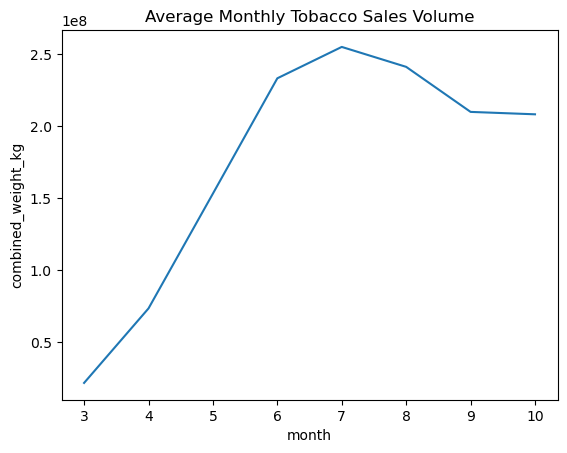

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

monthly_summary = df.groupby(['month']).agg({
    'combined_weight_kg':'mean',
    'combined_price_usd':'mean'
}).reset_index()

sns.lineplot(data=monthly_summary, x='month', y='combined_weight_kg')
plt.title('Average Monthly Tobacco Sales Volume')
plt.show()


C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


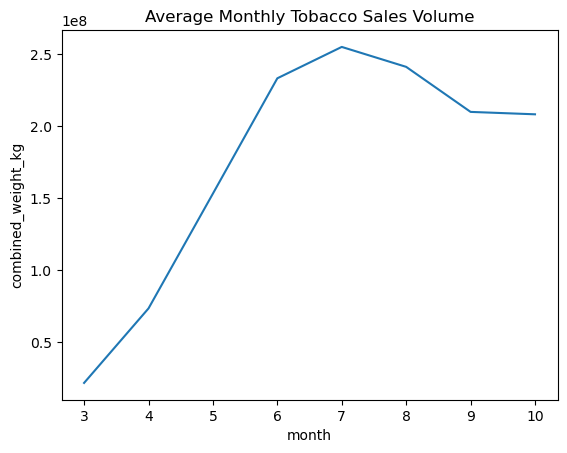

In [34]:
monthly_summary = df.groupby(['month']).agg({
    'combined_weight_kg':'mean',
    'combined_price_usd':'mean'
}).reset_index()

sns.lineplot(data=monthly_summary, x='month', y='combined_weight_kg')
plt.title('Average Monthly Tobacco Sales Volume')
plt.show()

ValueError: You must specify a period or x must be a pandas object with a PeriodIndex or a DatetimeIndex with a freq not set to None

In [35]:
def get_zim_season(month):
    if month in [11, 12, 1, 2, 3]:
        return "Rainy (Nov–Mar)"
    elif month in [4, 5, 6]:
        return "Post-rain/Harvest (Apr–Jun)"
    elif month in [7, 8]:
        return "Cool Dry (Jul–Aug)"
    elif month in [9, 10]:
        return "Hot Dry (Sep–Oct)"
    return "Unknown"

df['season'] = df['month'].apply(get_zim_season)


C:\Users\user\AppData\Local\Temp\ipykernel_6024\3572127973.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ts = df.set_index('date')['combined_price_usd'].resample('M').mean()
C:\Users\user\AppData\Local\Temp\ipykernel_6024\3572127973.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ts = ts.asfreq('M')


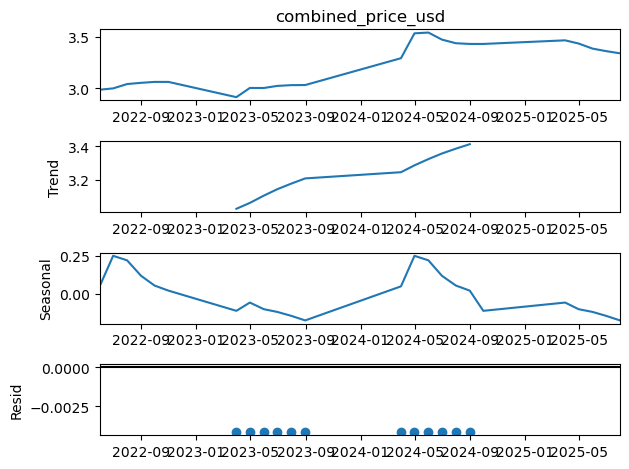

In [36]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Resample to monthly prices
ts = df.set_index('date')['combined_price_usd'].resample('M').mean()
ts = ts.asfreq('M')

# Decompose with yearly cycle
result = seasonal_decompose(ts.dropna(), model='additive', period=12)
result.plot()
plt.show()


In [37]:
seasonal_summary = df.groupby(['year','season']).agg({
    'combined_weight_kg':'sum',
    'combined_price_usd':'mean'
}).reset_index()

print(seasonal_summary.head())


   year                       season  combined_weight_kg  combined_price_usd
0  2022           Cool Dry (Jul–Aug)        5.305764e+09            3.043289
1  2022            Hot Dry (Sep–Oct)        2.915909e+09            3.060000
2  2022  Post-rain/Harvest (Apr–Jun)        3.271784e+09            2.989671
3  2023           Cool Dry (Jul–Aug)        9.323457e+09            3.028812
4  2023  Post-rain/Harvest (Apr–Jun)        1.035252e+10            3.008544


In [38]:
import pandas as pd
import numpy as np

# 1) monthly sales panel
sales = df.copy()

# ensure date is datetime and the index is monthly
sales['date'] = pd.to_datetime(sales['date'])
sales['year'] = sales['date'].dt.year
sales['month'] = sales['date'].dt.month
sales['ym'] = sales['date'].dt.to_period('M').dt.to_timestamp()

sales_m = (sales
           .groupby('ym', as_index=False)
           .agg(
               combined_weight_kg=('combined_weight_kg','sum'),
               combined_price_usd=('combined_price_usd','mean'),
               auction_weight_kg=('auction_weight_kg','sum'),
               contract_weight_kg=('contract_weight_kg','sum'),
               auction_price_usd=('auction_price_usd','mean'),
               contract_price_usd=('contract_price_usd','mean'),
               rejection_rate_auction=('rejection_rate_auction','mean'),
               rejection_rate_contract=('rejection_rate_contract','mean')
           ))

# helper price gap & weight gap at monthly level
sales_m['price_gap_ac']  = sales_m['auction_price_usd'] - sales_m['contract_price_usd']
sales_m['weight_gap_ac'] = sales_m['auction_weight_kg'] - sales_m['contract_weight_kg']

# Zimbabwe seasons: OND, JFM, AMJ, JAS
m = sales_m['ym'].dt.month
def zim_season(m):
    if m in [10,11,12]: return 'OND'
    if m in [1,2,3]:    return 'JFM'
    if m in [4,5,6]:    return 'AMJ'
    return 'JAS'        # 7,8,9

sales_m['season'] = [zim_season(x) for x in m]

# month & year columns for joins/plots
sales_m['year']  = sales_m['ym'].dt.year
sales_m['month'] = sales_m['ym'].dt.month


In [45]:
import pandas as pd

# --- Step 1: Ensure numeric dtypes ---
rain_df['year'] = pd.to_numeric(rain_df['year'], errors='coerce')
rain_df['month'] = pd.to_numeric(rain_df['month'], errors='coerce')

# --- Step 2: Drop missing year/month ---
rain_df = rain_df.dropna(subset=['year', 'month'])

# --- Step 3: Cast to integers ---
rain_df['year'] = rain_df['year'].astype(int)
rain_df['month'] = rain_df['month'].astype(int)

# --- Step 4: Create proper datetime column (first of each month) ---
rain_df['date'] = pd.to_datetime(
    rain_df['year'].astype(str) + "-" + rain_df['month'].astype(str) + "-01",
    format="%Y-%m-%d"
)

# --- Step 5: Filter only 2015–2025 ---
rain_df = rain_df[(rain_df['year'] >= 2015) & (rain_df['year'] <= 2025)]

# --- Step 6: Optional: set date as index ---
rain_df = rain_df.set_index('date').sort_index()

print(rain_df.head())
print(rain_df.tail())


            year  rainfall_mm  month
date                                
2015-01-01  2015        140.1      1
2015-02-01  2015         90.9      2
2015-03-01  2015         77.8      3
2015-05-01  2015          2.2      5
2015-08-01  2015          0.1      8
            year  rainfall_mm  month
date                                
2023-05-01  2023         0.50      5
2023-08-01  2023         3.90      8
2023-10-01  2023        52.90     10
2023-11-01  2023        19.20     11
2023-12-01  2023       184.71     12


C:\Users\user\AppData\Local\Temp\ipykernel_6024\3347475260.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rain_df['year'] = rain_df['year'].astype(int)
C:\Users\user\AppData\Local\Temp\ipykernel_6024\3347475260.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rain_df['month'] = rain_df['month'].astype(int)
C:\Users\user\AppData\Local\Temp\ipykernel_6024\3347475260.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_index

In [49]:
# Ensure month is integer
df['month'] = df['month'].astype(int)

# Create a Year-Month datetime column
df['ym'] = pd.to_datetime(
    df['year'].astype(str) + '-' + df['month'].astype(str) + '-01'
)

# Set as panel
panel = df.sort_values('ym').reset_index(drop=True)
panel.head()


,date,year,day_number,auction_weight_kg,auction_price_usd,contract_weight_kg,contract_price_usd,combined_weight_kg,combined_price_usd,rejection_rate_auction,...,month,week,quarter,price_gap_ac,weight_gap_ac,total_rejection_pressure,rolling_avg_price,rolling_rejection_rate,season,ym
0,2022-05-06,2022,25,4742300,3.15,60087393.0,2.94,64829693.0,2.955362,11.94,...,5,18,2,0.21,-55345093.0,1.852101e+08,2.982054,6.857857,Post-rain/Harvest (Apr–Jun),2022-05-01
1,2022-05-31,2022,41,8041436,3.15,111907645.0,2.99,119949081.0,3.000726,11.42,...,5,22,2,0.16,-103866209.0,3.313156e+08,2.993068,6.920714,Post-rain/Harvest (Apr–Jun),2022-05-01
2,2022-05-30,2022,40,7821019,3.14,108486740.0,2.98,116307759.0,2.990759,11.44,...,5,22,2,0.16,-100665721.0,3.216341e+08,2.992802,6.899643,Post-rain/Harvest (Apr–Jun),2022-05-01
3,2022-05-27,2022,39,7651773,3.14,105938211.0,2.98,113589984.0,2.990778,11.43,...,5,21,2,0.16,-98286438.0,3.141675e+08,2.992632,6.879286,Post-rain/Harvest (Apr–Jun),2022-05-01
4,2022-05-26,2022,38,7504674,3.14,102773093.0,2.97,110277767.0,2.981569,11.45,...,5,21,2,0.17,-95268419.0,3.058629e+08,2.991139,6.860714,Post-rain/Harvest (Apr–Jun),2022-05-01


In [53]:
ts_price = (
    panel.groupby('ym')['combined_price_usd']   # group by month
    .mean()                                     # average price for the month
    .asfreq('MS')                               # monthly frequency
    .interpolate()                              # fill any gaps
)


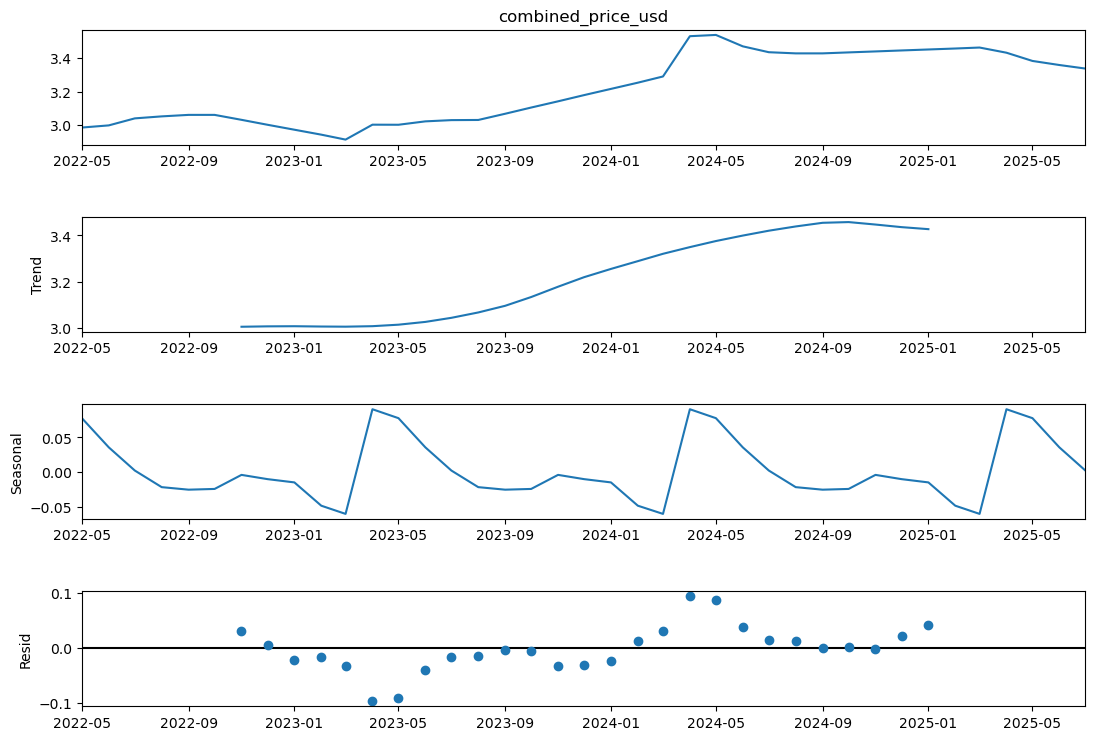

In [54]:
from statsmodels.tsa.seasonal import seasonal_decompose

res = seasonal_decompose(ts_price, model='additive', period=12)
fig = res.plot()
fig.set_size_inches(12, 8)


In [55]:
import pandas as pd

# Aggregate monthly to ensure unique 'ym' per month
monthly_panel = panel.groupby('ym').agg({
    'combined_price_usd': 'mean',
    'combined_weight_kg': 'sum',
    'auction_price_usd': 'mean',
    'contract_price_usd': 'mean',
    'auction_weight_kg': 'sum',
    'contract_weight_kg': 'sum',
    'rejection_rate_auction': 'mean',
    'rejection_rate_contract': 'mean'
}).sort_index()


In [56]:
#prepare time series
ts_price = monthly_panel['combined_price_usd'].asfreq('MS').interpolate()
ts_weight = monthly_panel['combined_weight_kg'].asfreq('MS').interpolate()


C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\base\model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


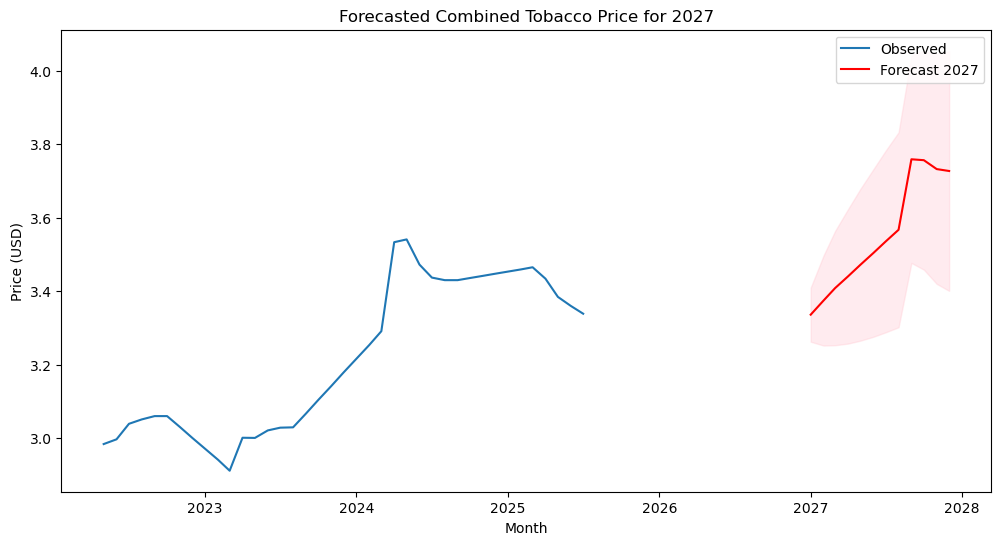

                 date  forecast_price_usd  lower_ci  upper_ci
2025-08-01 2027-01-01            3.336067  3.262443  3.409691
2025-09-01 2027-02-01            3.374527  3.252013  3.497041
2025-10-01 2027-03-01            3.408519  3.252921  3.564117
2025-11-01 2027-04-01            3.440237  3.257362  3.623113
2025-12-01 2027-05-01            3.471951  3.265375  3.678527
2026-01-01 2027-06-01            3.503665  3.275841  3.731489
2026-02-01 2027-07-01            3.535378  3.288125  3.782631
2026-03-01 2027-08-01            3.567111  3.301849  3.832374
2026-04-01 2027-09-01            3.758991  3.476861  4.041121
2026-05-01 2027-10-01            3.756523  3.458585  4.054461
2026-06-01 2027-11-01            3.732308  3.419915  4.044700
2026-07-01 2027-12-01            3.727086  3.400880  4.053292


In [59]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# --- Ensure monthly panel is aggregated ---
monthly_panel = panel.groupby('ym').agg({
    'combined_price_usd':'mean',
    'combined_weight_kg':'sum',
    'auction_price_usd':'mean',
    'contract_price_usd':'mean',
    'auction_weight_kg':'sum',
    'contract_weight_kg':'sum',
    'rejection_rate_auction':'mean',
    'rejection_rate_contract':'mean'
}).sort_index()

# --- Merge climate & inflation ---
merged_df['ym'] = pd.to_datetime(merged_df['year'].astype(str) + '-' + merged_df['month'].astype(str) + '-01')
monthly_data = pd.merge(monthly_panel, merged_df[['ym','avg_temp_c','rainfall_mm','inflation_rate_pct']], on='ym', how='left')
monthly_data[['avg_temp_c','rainfall_mm','inflation_rate_pct']] = monthly_data[['avg_temp_c','rainfall_mm','inflation_rate_pct']].interpolate()

# --- Time series & exogenous alignment ---
ts_price = monthly_data.set_index('ym')['combined_price_usd'].asfreq('MS').interpolate()
exog = monthly_data.set_index('ym')[['avg_temp_c','rainfall_mm','inflation_rate_pct']].reindex(ts_price.index).interpolate()

# --- Fit SARIMAX with exogenous variables ---
model = SARIMAX(ts_price, order=(1,1,1), seasonal_order=(1,1,1,12), exog=exog)
fit_model = model.fit(disp=False)

# --- Forecast function ---
def forecast_tobacco_price(year, fit_model=fit_model, exog=exog):
    future_dates = pd.date_range(start=f'{year}-01-01', end=f'{year}-12-01', freq='MS')
    
    # Use last 12 months of exog as proxy
    last_exog = exog.iloc[-12:]
    future_exog = last_exog.copy()
    future_exog.index = future_dates

    # Forecast
    forecast_res = fit_model.get_forecast(steps=12, exog=future_exog)
    forecast_df = pd.DataFrame({
        'date': future_dates,
        'forecast_price_usd': forecast_res.predicted_mean,
        'lower_ci': forecast_res.conf_int().iloc[:,0],
        'upper_ci': forecast_res.conf_int().iloc[:,1]
    })

    # Plot
    plt.figure(figsize=(12,6))
    plt.plot(ts_price, label='Observed')
    plt.plot(forecast_df['date'], forecast_df['forecast_price_usd'], color='red', label=f'Forecast {year}')
    plt.fill_between(forecast_df['date'], forecast_df['lower_ci'], forecast_df['upper_ci'], color='pink', alpha=0.3)
    plt.title(f'Forecasted Combined Tobacco Price for {year}')
    plt.xlabel('Month')
    plt.ylabel('Price (USD)')
    plt.legend()
    plt.show()
    
    return forecast_df

# --- Example usage ---
forecast_2027 = forecast_tobacco_price(2027)
print(forecast_2027)
